<a href="https://colab.research.google.com/github/ElizabethFrankWebb/USRI-2026/blob/main/Individual_Base_Model_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as ns

In [76]:
#@title parameters

intial_population = 100
loci = 5
selection = 10
optimal_trait_value = 0
mutation_rate = 10**-2
generation = 100 #@param {type:"integer"}
genotypes = np.zeros((intial_population, loci))

In [77]:
# Calculate trait value for all individuals

def calculate_trait_z(individual_genotype):
  trait_value = np.sum(individual_genotype)
  return trait_value
trait_values = np.array([calculate_trait_z(individual) for individual in genotypes])

print("Trait values for all individuals:")
print(trait_values)


Trait values for all individuals:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


In [78]:
def calculate_fitness(trait_values, optimal_trait_value, selection):
  trait_values = np.asarray(trait_values)
  fitness = np.exp(-(trait_values - optimal_trait_value)**2 / (2 * selection))
  return fitness # Added return statement here

population_fitness = calculate_fitness(trait_values, optimal_trait_value, selection)

print(population_fitness)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


In [79]:
#next generation with asexual mating using poisson distrbution for number of offsring


lambdas = population_fitness

offspring_counts = np.random.poisson(lambdas)

print(offspring_counts)

[1 1 0 3 0 0 1 1 3 3 1 2 1 1 2 0 0 0 1 3 0 0 2 3 0 1 2 0 0 0 0 3 2 1 1 2 1
 0 0 0 1 2 2 0 1 2 0 1 1 3 1 1 1 1 0 1 0 1 1 3 1 1 1 3 0 2 0 0 0 1 0 0 1 0
 3 3 0 0 2 0 1 0 0 0 3 1 0 1 2 1 3 2 0 1 0 2 3 0 2 1]


In [80]:
# introducing mutation

def mutate(individual, mutation_rate):
  mutated_individual = individual.copy()
  mutated_loci_info = [] # Store (locus_index, original_value, new_value)
  for locus in range(len(individual)):
    if np.random.rand() < mutation_rate:
      original_value = individual[locus] # Get original value before mutation
      new_value = np.random.normal(0,1) # Assign new value from normal distribution (mean=0, std=1)
      mutated_individual[locus] = new_value
      mutated_loci_info.append((locus, original_value, new_value))
  return mutated_individual, mutated_loci_info # Return both the mutated individual and info about mutations

In [81]:
# Generate the next generation with mutations
new_gen_genotypes_list = []
offspring_mutation_details = []
offspring_counter = 0

# Ensure intial_population is updated to reflect the current size of genotypes array
current_population_size = len(genotypes)

for parent_idx in range(current_population_size):
    parent_genotype = genotypes[parent_idx]
    num_offspring = offspring_counts[parent_idx]

    for _ in range(num_offspring):
        mutated_individual, mutated_loci_info = mutate(parent_genotype, mutation_rate)
        new_gen_genotypes_list.append(mutated_individual)

        if mutated_loci_info:
            offspring_mutation_details.append({
                'offspring_idx': offspring_counter,
                'parent_idx': parent_idx,
                'mutations': mutated_loci_info
            })
        offspring_counter += 1

# Update the genotypes for the new generation
if new_gen_genotypes_list:
    genotypes = np.array(new_gen_genotypes_list)
    intial_population = len(genotypes) # Update population size for the next generation
else:
    genotypes = np.empty((0, loci)) # Handle case with no offspring
    intial_population = 0

print("--- New Generation Genotypes with Mutations ---")
if intial_population > 0:
    for i, individual_genotype in enumerate(genotypes):
        print(f"Offspring {i}: Genotype = {individual_genotype}")
else:
    print("No offspring were generated in this generation.")

print("\n--- Mutation Details ---")
if offspring_mutation_details:
    for detail in offspring_mutation_details:
        print(f"Offspring {detail['offspring_idx']} (from Parent {detail['parent_idx']}) mutated at:")
        for locus_idx, original_val, new_val in detail['mutations']:
            print(f"  Locus {locus_idx}: Changed from {original_val:.4f} to {new_val:.4f}")
else:
    print("No mutations occurred in this generation.")

# Recalculate trait values for the new generation
if intial_population > 0:
    trait_values = np.array([calculate_trait_z(individual) for individual in genotypes])
    print(f"\nRecalculated Trait values for new generation ({intial_population} individuals):")
    print(trait_values)

    # Recalculate fitness for the new generation
    population_fitness = calculate_fitness(trait_values, optimal_trait_value, selection)
    print(f"\nRecalculated Fitness for new generation ({intial_population} individuals):")
    print(population_fitness)
else:
    print("\nCannot recalculate trait values or fitness as no offspring were generated.")

--- New Generation Genotypes with Mutations ---
Offspring 0: Genotype = [0. 0. 0. 0. 0.]
Offspring 1: Genotype = [0.29098865 0.         0.         0.         0.        ]
Offspring 2: Genotype = [0. 0. 0. 0. 0.]
Offspring 3: Genotype = [0. 0. 0. 0. 0.]
Offspring 4: Genotype = [0. 0. 0. 0. 0.]
Offspring 5: Genotype = [0. 0. 0. 0. 0.]
Offspring 6: Genotype = [0. 0. 0. 0. 0.]
Offspring 7: Genotype = [0. 0. 0. 0. 0.]
Offspring 8: Genotype = [0. 0. 0. 0. 0.]
Offspring 9: Genotype = [0. 0. 0. 0. 0.]
Offspring 10: Genotype = [0. 0. 0. 0. 0.]
Offspring 11: Genotype = [0. 0. 0. 0. 0.]
Offspring 12: Genotype = [0. 0. 0. 0. 0.]
Offspring 13: Genotype = [0. 0. 0. 0. 0.]
Offspring 14: Genotype = [0. 0. 0. 0. 0.]
Offspring 15: Genotype = [0. 0. 0. 0. 0.]
Offspring 16: Genotype = [0. 0. 0. 0. 0.]
Offspring 17: Genotype = [0. 0. 0. 0. 0.]
Offspring 18: Genotype = [0. 0. 0. 0. 0.]
Offspring 19: Genotype = [0. 0. 0. 0. 0.]
Offspring 20: Genotype = [0. 0. 0. 0. 0.]
Offspring 21: Genotype = [0. 0. 0. 0. 0.

### Simulation Loop

In [82]:
fitness_history = [] # Initialize list to store fitness data for each generation

for g in range(generation):
    #print(f"\n{'='*30} GENERATION {g+1} {'='*30}")

    # Recalculate lambdas for offspring counts based on current population fitness
    lambdas = population_fitness
    offspring_counts = np.random.poisson(lambdas)

    # Generate the next generation with mutations
    new_gen_genotypes_list = []
    offspring_mutation_details = []
    offspring_counter = 0

    # Ensure intial_population is updated to reflect the current size of genotypes array
    current_population_size = len(genotypes)

    for parent_idx in range(current_population_size):
        parent_genotype = genotypes[parent_idx]
        num_offspring = offspring_counts[parent_idx]

        for _ in range(num_offspring):
            mutated_individual, mutated_loci_info = mutate(parent_genotype, mutation_rate)
            new_gen_genotypes_list.append(mutated_individual)

            if mutated_loci_info:
                offspring_mutation_details.append({
                    'offspring_idx': offspring_counter,
                    'parent_idx': parent_idx,
                    'mutations': mutated_loci_info
                })
            offspring_counter += 1

    # Update the genotypes for the new generation
    if new_gen_genotypes_list:
        genotypes = np.array(new_gen_genotypes_list)
        intial_population = len(genotypes) # Update population size for the next generation
    else:
        genotypes = np.empty((0, loci)) # Handle case with no offspring
        intial_population = 0

    #print(f"\n--- GENERATION {g+1}: New Generation Genotypes with Mutations ---")
    if intial_population > 0:
        for i, individual_genotype in enumerate(genotypes):
            #print(f"Offspring {i}: Genotype = {individual_genotype}")
            pass # Added to resolve IndentationError
    #else:
        #print("No offspring were generated in this generation.")

    #print(f"\n--- GENERATION {g+1}: Mutation Details ---")
    #if offspring_mutation_details:
        #for detail in offspring_mutation_details:
            #print(f"Offspring {detail['offspring_idx']} (from Parent {detail['parent_idx']}) mutated at:")
            #for locus_idx, original_val, new_val in detail['mutations']:
                #print(f"  Locus {locus_idx}: Changed from {original_val:.4f} to {new_val:.4f}")
    #else:
        #print("No mutations occurred in this generation.")

    # Recalculate trait values for the new generation AND store fitness
    if intial_population > 0:
        trait_values = np.array([calculate_trait_z(individual) for individual in genotypes])
        #print(f"\nGENERATION {g+1}: Recalculated Trait values for new generation ({intial_population} individuals):")
        #print(trait_values)

        # Recalculate fitness for the new generation
        population_fitness = calculate_fitness(trait_values, optimal_trait_value, selection)
        #print(f"\nGENERATION {g+1}: Recalculated Fitness for new generation ({intial_population} individuals):")
        #print(population_fitness)
        fitness_history.append(population_fitness.copy()) # Store the fitness values for this generation
    else:
        # If the population goes extinct, record an empty array for this generation's fitness
        # This ensures fitness_history has an entry for every generation
        fitness_history.append(np.array([]))
        pass # Added to resolve SyntaxError

/tmp/ipykernel_1503/546634337.py:9: UserWarning: 

The `a` parameter has been replaced; use `x`, `y`, and/or `data` instead.
Please update your code; This will become an error in seaborn v0.14.0.

  ns.rugplot(a=final_generation_fitness, color="darkblue", height=0.05)


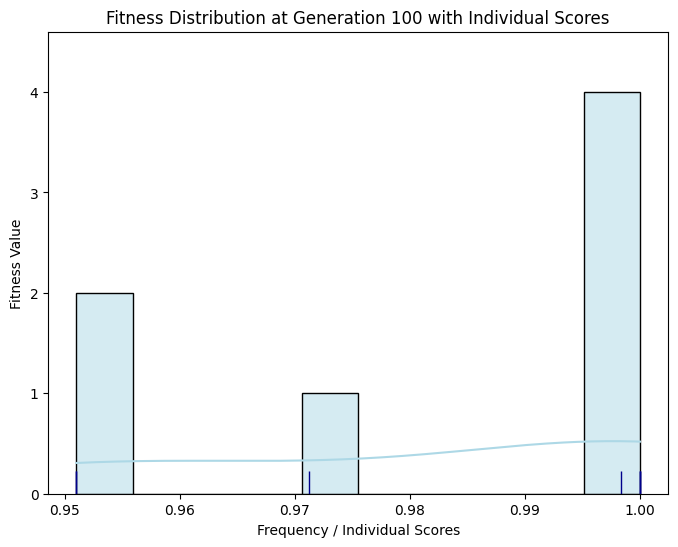

In [83]:
#Plotting the distribution of fitness values for the final generation

final_generation_fitness = fitness_history[-1]

if len(final_generation_fitness) > 0:
    plt.figure(figsize=(8, 6))
    ns.histplot(data=final_generation_fitness, bins=10, kde=True, color="lightblue")
    # Add rugplot to show individual fitness scores
    ns.rugplot(a=final_generation_fitness, color="darkblue", height=0.05)
    plt.title(f"Fitness Distribution at Generation {generation} with Individual Scores")
    plt.xlabel("Frequency / Individual Scores")
    plt.ylabel("Fitness Value")
    plt.show()
else:
    print(f"Population went extinct before or at Generation {generation}. No fitness data to plot.")